# RQ1 – Baseline Predictability of Pit Stops

Kaggle-ready notebook. It loads the raw F1 strategy dataset, generates the actual table and publication-ready PDF figure for this research question, and saves results in `outputs/`.

In [35]:

# Kaggle-ready setup: imports, dataset loading, preprocessing helpers
import os, glob, warnings, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

RANDOM_STATE = 42
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Publication plotting defaults
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

def find_dataset_file():
    """Finds a CSV/XLSX file in Kaggle input or current working directory."""
    patterns = [
        '/kaggle/input/**/*.csv', '/kaggle/input/**/*.xlsx', '/kaggle/input/**/*.xls',
        './**/*.csv', './**/*.xlsx', './**/*.xls',
        '/mnt/data/*.csv', '/mnt/data/*.xlsx', '/mnt/data/*.xls'
    ]
    files = []
    for p in patterns:
        files.extend(glob.glob(p, recursive=True))
    files = [f for f in files if not os.path.basename(f).startswith('RQ')]
    if not files:
        raise FileNotFoundError('No CSV/XLSX dataset found. On Kaggle, attach the F1 Strategy Dataset using Add Data.')
    # Prefer f1 strategy file names, otherwise largest file
    preferred = [f for f in files if 'f1' in os.path.basename(f).lower() or 'strategy' in os.path.basename(f).lower()]
    candidates = preferred or files
    candidates = sorted(candidates, key=lambda f: os.path.getsize(f), reverse=True)
    return candidates[0]

def load_data():
    path = find_dataset_file()
    print('Loading dataset:', path)
    if path.lower().endswith('.csv'):
        df = pd.read_csv(path)
    else:
        df = pd.read_excel(path)
    print('Shape:', df.shape)
    print('Columns:', list(df.columns))
    return df

def validate_columns(df):
    required = {'PitNextLap'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f'Missing required target column(s): {missing}')
    return True

def get_feature_columns(df, requested=None):
    leakage_cols = {'PitNextLap', 'PitStop'}
    if requested is None:
        cols = [c for c in df.columns if c not in leakage_cols]
    else:
        cols = [c for c in requested if c in df.columns and c not in leakage_cols]
    return cols

def make_preprocessor(X):
    cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    return ColumnTransformer([
        ('num', numeric_pipeline, num_cols),
        ('cat', categorical_pipeline, cat_cols)
    ]), num_cols, cat_cols

def make_pipeline(model, X):
    preprocessor, _, _ = make_preprocessor(X)
    return Pipeline([('preprocess', preprocessor), ('model', model)])

def train_test(df, features=None, test_size=0.2):
    validate_columns(df)
    features = get_feature_columns(df, features)
    X = df[features].copy()
    y = df['PitNextLap'].astype(int).copy()
    return train_test_split(X, y, test_size=test_size, stratify=y, random_state=RANDOM_STATE)

def predict_scores(pipe, X_test):
    y_pred = pipe.predict(X_test)
    y_score = None
    if hasattr(pipe, 'predict_proba'):
        try:
            y_score = pipe.predict_proba(X_test)[:, 1]
        except Exception:
            y_score = None
    if y_score is None and hasattr(pipe, 'decision_function'):
        try:
            y_score = pipe.decision_function(X_test)
        except Exception:
            y_score = None
    return y_pred, y_score

def metric_row(model_name, y_true, y_pred, y_score=None):
    row = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-score': f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        try:
            row['AUC'] = roc_auc_score(y_true, y_score)
        except Exception:
            row['AUC'] = np.nan
    return row

def xgb_model():
    if HAS_XGB:
        return XGBClassifier(
            n_estimators=250, max_depth=4, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9,
            eval_metric='logloss', random_state=RANDOM_STATE,
            n_jobs=-1
        )
    return RandomForestClassifier(n_estimators=250, random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced')

def save_table(df, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(path, index=False)
    print('Saved table:', path)
    return path

def save_fig(filename):
    path = os.path.join(OUTPUT_DIR, filename)
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    print('Saved figure:', path)
    plt.show()
    return path

def format_scores(df, cols=None):
    out = df.copy()
    cols = cols or [c for c in out.columns if c not in ['Model', 'Scenario', 'Feature Set', 'Feature', 'Rank', 'Criterion', 'Selected']]
    for c in cols:
        if c in out.columns and pd.api.types.is_numeric_dtype(out[c]):
            out[c] = out[c].round(4)
    return out


## RQ1: How accurately can baseline supervised learning models predict whether a driver will pit on the next lap?

In [36]:

df = load_data()
validate_columns(df)
print(df['PitNextLap'].value_counts(normalize=True).rename('Proportion'))
X_train, X_test, y_train, y_test = train_test(df)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=RANDOM_STATE),
    'k-NN': KNeighborsClassifier(n_neighbors=15)
}
rows = []
for name, model in models.items():
    pipe = make_pipeline(model, X_train)
    pipe.fit(X_train, y_train)
    y_pred, y_score = predict_scores(pipe, X_test)
    rows.append(metric_row(name, y_test, y_pred, y_score))

results = format_scores(pd.DataFrame(rows))
save_table(results, 'RQ1_baseline_model_performance.csv')
results


Loading dataset: /kaggle/input/datasets/slaokutucu/f1-strategy-dataset-pitstop-prediction/f1_strategy_dataset_v4.csv
Shape: (101371, 16)
Columns: ['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'Race', 'Year', 'LapTime_Delta', 'Cumulative_Degradation', 'PitStop', 'PitNextLap', 'RaceProgress', 'Normalized_TyreLife', 'Position_Change']
PitNextLap
0    0.745203
1    0.254797
Name: Proportion, dtype: float64
Saved table: outputs/RQ1_baseline_model_performance.csv


,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression,0.7276,0.4779,0.7435,0.5818,0.8039
1,Decision Tree,0.8132,0.5884,0.8887,0.7080,0.9015
2,k-NN,0.9329,0.8920,0.8380,0.8642,0.9753


Saved figure: outputs/RQ1_baseline_model_performance.pdf


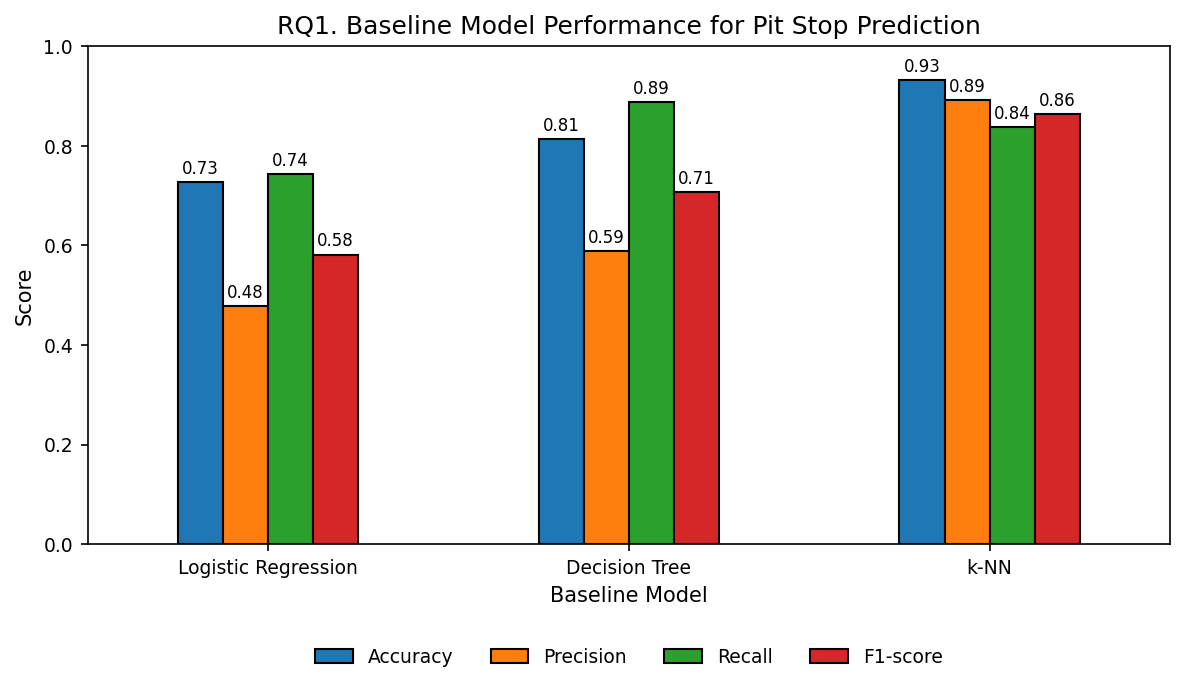

'outputs/RQ1_baseline_model_performance.pdf'

In [37]:

plot_df = results.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-score']]
ax = plot_df.plot(kind='bar', figsize=(8, 4.8), rot=0, edgecolor='black')
ax.set_title('RQ1. Baseline Model Performance for Pit Stop Prediction')
ax.set_xlabel('Baseline Model')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(ncol=4, loc='lower center', bbox_to_anchor=(0.5, -0.28), frameon=False)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8, padding=2)
save_fig('RQ1_baseline_model_performance.pdf')
